In [18]:
import sys
sys.path.append("../src")

import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns
import info
import loader
import stats
import plotter

dataset_path = "../dataset/features.csv"
    
try:
    df = loader.load_data(dataset_path)
except FileNotFoundError as e:
    print(f"Error: dataset file ({dataset_path}) not found")
    sys.exit(1)

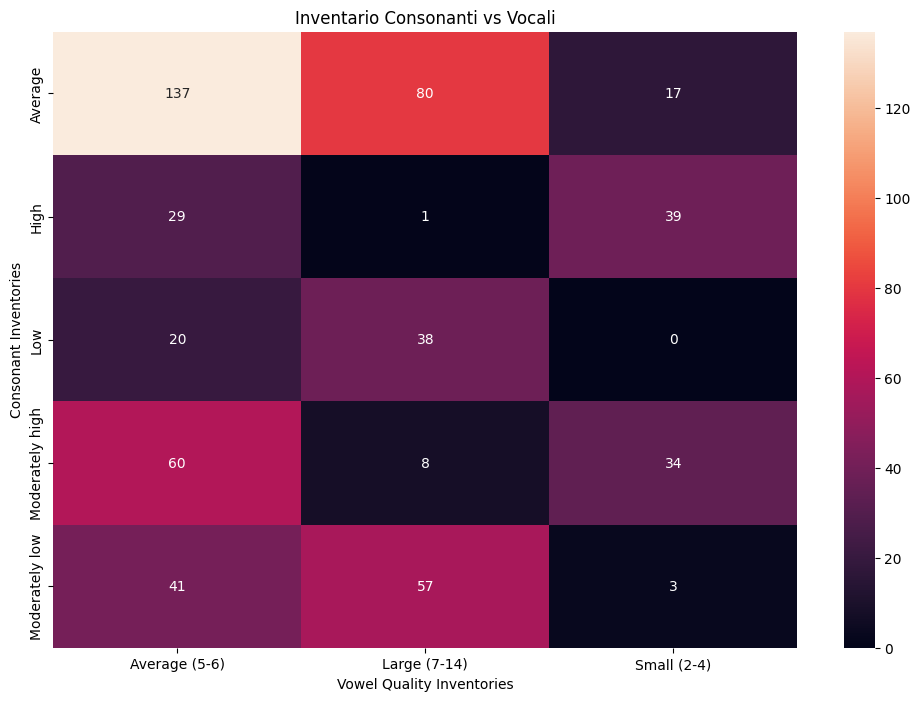

In [21]:
params = ['3A', '2A']
qdf = df.copy()
qdf = stats.filter(qdf, "Parameter_ID", params) 
qdf = qdf[["Language_ID", "Parameter_ID", "Code_Name"]]

# Certe lingue sono registrate per più paesi quindi ci sarebbero dei duplicati
qdf = qdf.drop_duplicates()

qdf = qdf.pivot(
    index='Language_ID', 
    columns='Parameter_ID', 
    values='Code_Name'
).dropna()

tabella_frequenze = pd.crosstab(qdf[params[0]], qdf[params[1]])

plt.figure(figsize=(12, 8))
sns.heatmap(tabella_frequenze, annot=True, fmt="d")
plt.title("Inventario Consonanti vs Vocali")
plt.ylabel("Consonant Inventories")
plt.xlabel("Vowel Quality Inventories")
plt.show()

